# 4-LORO comparison between positive and negative samples

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold
from rdkit import Chem
from rdkit.Chem import Draw
from scipy.stats import pearsonr

from dative_chemprop.models.DativeCGR import DativeCGR

torch.set_float32_matmul_precision("high")

chemprop_dir = Path.cwd()
random_seed = 42
n_folds = 5
data_splits = [
    (
        pd.read_csv(
            chemprop_dir / "data" / "OOS" / f"train_OOS_{i + 1}.csv", index_col=0
        ),
        pd.read_csv(
            chemprop_dir / "data" / "OOS" / f"test_OOS_{i + 1}.csv", index_col=0
        ),
    )
    for i in range(17)
]

## Naive method

In [2]:
rxn_smiles_columns = [
    "rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets

batch_size = 128
result_dfs = []
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    model = DativeCGR(
        model_name=f"1-naive_{idx}",
        seed=random_seed,
    )
    if not os.path.exists(model.model_path):
        model.fit(
            train_smis.flatten(),
            train_y.repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=600,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
        )
    pred = model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "method": ["naive"] * len(test_data.index),
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

Loaded model from .checkpoints/1-naive_0_reac_prod.pt.


/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= 0.20498058485583148
MAE= 0.5269128377516784
Pearson R= 0.5517659246173613
Loaded model from .checkpoints/1-naive_1_reac_prod.pt.


/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.8188726592160587
MAE= 0.6373383632900309
Pearson R= 0.14500602982693378
Loaded model from .checkpoints/1-naive_16_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= -2.107761359750654
MAE= 1.0142296922666598
Pearson R= 0.3064245801625168


## Data augmentation

### negative augmented

In [3]:
rxn_smiles_columns = [
    "rxn_smiles",
    "pesudo_active_donor_rxn_smiles",
    "no_extra_dative_rxn_smiles",
    "no_extra_dative_pesudo_active_donor_rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets

batch_size = 128
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    model = DativeCGR(
        model_name=f"2-pesudo_{idx}",
        seed=random_seed,
    )
    if not os.path.exists(model.model_path):
        model.fit(
            train_smis.flatten(),
            train_y.repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=600,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
        )
    pred = model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "method": ["negative augmented"] * len(test_data.index),
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Loaded model from .checkpoints/2-pesudo_0_reac_prod.pt.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.44778488373324854
MAE= 0.6153490889678975
Pearson R= 0.09333161068284651
Loaded model from .checkpoints/2-pesudo_16_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= -1.0636947848755818
MAE= 0.8446585780290156
Pearson R= 0.40892211411275364


### positive augmented

In [4]:
rxn_smiles_columns = [
    "rxn_smiles",
    "rxn_active_smiles",
    "dative_active_rxn_smiles",
    "dative_rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets

batch_size = 128
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    model = DativeCGR(
        model_name=f"3-hybrid_{idx}",
        seed=random_seed,
    )
    if not os.path.exists(model.model_path):
        model.fit(
            train_smis.flatten(),
            train_y.repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=600,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
        )
    pred = model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "method": ["positive augmented"] * len(test_data.index),
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Loaded model from .checkpoints/3-hybrid_0_reac_prod.pt.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.751759059226458
MAE= 0.6612255000102026
Pearson R= -0.05262694372559012
Loaded model from .checkpoints/3-hybrid_16_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= -1.0869061398881414
MAE= 0.8229222338696713
Pearson R= 0.4316944653242534


## Comparison of positive and negative augmented methods

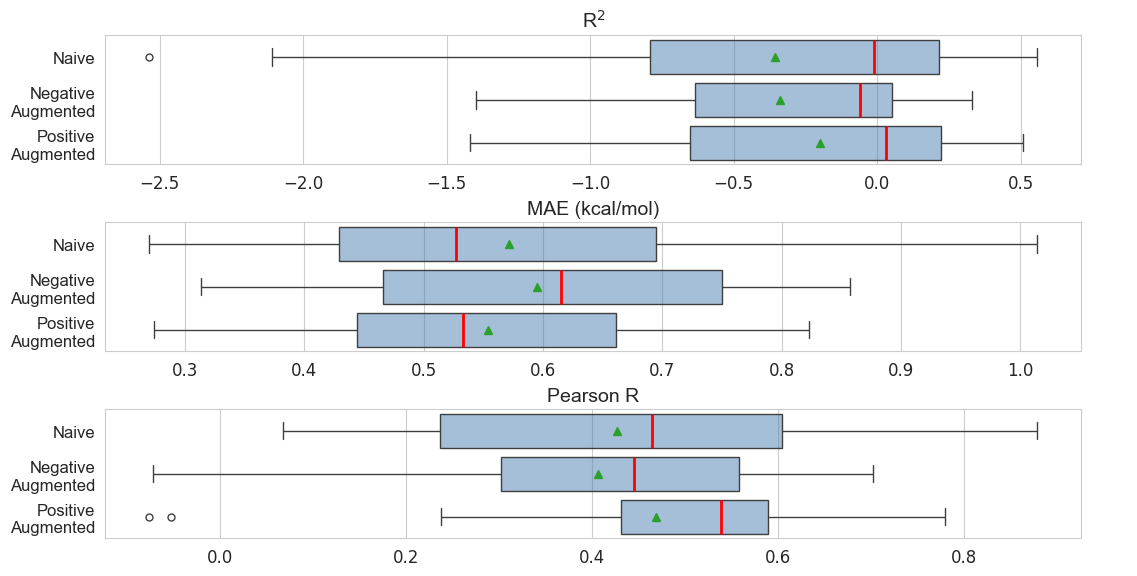

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


selected_methods = {
    "naive": "Naive",
    "negative augmented": "Negative\nAugmented",
    "positive augmented": "Positive\nAugmented",
}
results = []
for df in result_dfs:
    method = df["method"].iloc[0]
    if method not in selected_methods:
        continue
    for label, subdf in df.groupby("idx"):
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "method": method,
                "metrics": "R$^2$",
                "value": r2_score(subdf["y_true"], subdf["y_pred"]),
            }
        )
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "method": method,
                "metrics": "MAE",
                "value": mean_absolute_error(subdf["y_true"], subdf["y_pred"]),
            }
        )
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "method": method,
                "metrics": "Pearson R",
                "value": pearsonr(subdf["y_true"], subdf["y_pred"])[0],
            }
        )
with sns.axes_style("whitegrid"):
    g = sns.catplot(
        pd.DataFrame(results),
        y="method",
        x="value",
        row="metrics",
        kind="box",
        sharex=False,
        boxprops={"facecolor": (0.3, 0.5, 0.7, 0.5)},
        medianprops={"color": "r", "linewidth": 2},
        facet_kws=dict(despine=False),
        showmeans=True,
    )
    g.figure.set_size_inches(12, 6)
    g.tight_layout()
    g.set_xlabels("")
    g.set_ylabels("")
    g.set_yticklabels(selected_methods.values(), fontfamily="Arial", fontsize=12)
    for idx, ((i, j, k), data_ijk) in enumerate(g.facet_data()):
        ax = g.facet_axis(i, j, k)
        if idx == 0:
            ax.set_title("R$^2$", fontsize=14, fontfamily="Arial")
        if idx == 1:
            ax.set_title("MAE (kcal/mol)", fontsize=14, fontfamily="Arial")
        if idx == 2:
            ax.set_title("Pearson R", fontsize=14, fontfamily="Arial")
    for idx, ((i, j, k), data_ijk) in enumerate(g.facet_data()):
        ax = g.facet_axis(i, j, k)
        for i, label in enumerate(ax.get_xticklabels()):
            label.set_fontsize(12)

## Weighted tuning

### positive augmented with negative weighted tuning


In [6]:
from skfp.fingerprints import ECFPFingerprint
from sklearn.metrics.pairwise import PAIRWISE_DISTANCE_FUNCTIONS

fpgen = ECFPFingerprint(radius=3, fp_size=2048, count=True)
rxn_smiles_columns = [
    "rxn_smiles",
    "rxn_active_smiles",
    "dative_active_rxn_smiles",
    "dative_rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets

batch_size = 128
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    retrain_model = DativeCGR(
        model_name=f"3-hybrid_{idx}_weighted_tuned_negative",
        seed=random_seed,
    )
    if not os.path.exists(model.model_path):
        base_model = DativeCGR(
            model_name=f"3-hybrid_{idx}",
            seed=random_seed,
        )
        retrain_model.load_from_checkpoint(base_model.model_path)
        target_acceptor = test_data["acceptor_smiles"].unique()[0]
        target_donor = test_data["donor_smiles"].unique()[0]
        weights = np.exp(
            PAIRWISE_DISTANCE_FUNCTIONS["cosine"](
                np.concatenate(
                    [
                        fpgen.transform(train_data["donor_smiles"]),
                        fpgen.transform(train_data["acceptor_smiles"]),
                    ],
                    axis=1,
                ),
                np.concatenate(
                    [
                        fpgen.transform([target_donor]),
                        fpgen.transform([target_acceptor]),
                    ],
                    axis=1,
                ),
            )
        )
        retrain_model.fit(
            train_smis.flatten(),
            (train_y * weights / weights.max()).repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=200,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
            devices=[1],
        )
    pred = retrain_model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "method": ["hybrid weighted_tuned_negative"] * len(test_data.index),
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Loaded model from .checkpoints/3-hybrid_0_weighted_tuned_negative_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -1.3932655683418758
MAE= 0.8603727725834673
Pearson R= 0.187154286969328
Loaded model from .checkpoints/3-hybrid_1_weighted_tuned_negative_reac_prod.pt.


...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.21915943662891113
MAE= 0.5502931677826636
Pearson R= -0.23144362124391646
Loaded model from .checkpoints/3-hybrid_16_weighted_tuned_negative_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= 0.06396108501088682
MAE= 0.5261778905287774
Pearson R= 0.29644944033591364


### positive augmented with positive weighted tuning

In [7]:
rxn_smiles_columns = [
    "rxn_smiles",
    "rxn_active_smiles",
    "dative_active_rxn_smiles",
    "dative_rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets

batch_size = 128
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    retrain_model = DativeCGR(
        model_name=f"3-hybrid_{idx}_weighted_tuned",
        seed=random_seed,
    )
    if not os.path.exists(retrain_model.model_path):
        base_model = DativeCGR(
            model_name=f"3-hybrid_{idx}",
            seed=random_seed,
        )
        retrain_model.load_from_checkpoint(base_model.model_path)
        target_acceptor = test_data["acceptor_smiles"].unique()[0]
        target_donor = test_data["donor_smiles"].unique()[0]
        weights = np.exp(
            -PAIRWISE_DISTANCE_FUNCTIONS["cosine"](
                np.concatenate(
                    [
                        fpgen.transform(train_data["donor_smiles"]),
                        fpgen.transform(train_data["acceptor_smiles"]),
                    ],
                    axis=1,
                ),
                np.concatenate(
                    [
                        fpgen.transform([target_donor]),
                        fpgen.transform([target_acceptor]),
                    ],
                    axis=1,
                ),
            )
        )
        retrain_model.fit(
            train_smis.flatten(),
            (train_y * weights / weights.max()).repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=200,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
            devices=[1],
        )
    pred = retrain_model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "method": ["hybrid weighted tuned"] * len(test_data.index),
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Loaded model from .checkpoints/3-hybrid_0_weighted_tuned_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= 0.47267784557388115
MAE= 0.3658781452326893
Pearson R= 0.6921140028209987
Loaded model from .checkpoints/3-hybrid_1_weighted_tuned_reac_prod.pt.


...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.18958174534701167
MAE= 0.5643276819257986
Pearson R= 0.14816746095481909
Loaded model from .checkpoints/3-hybrid_16_weighted_tuned_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= -1.0403691008254037
MAE= 0.7971748724791843
Pearson R= 0.45375826837445765


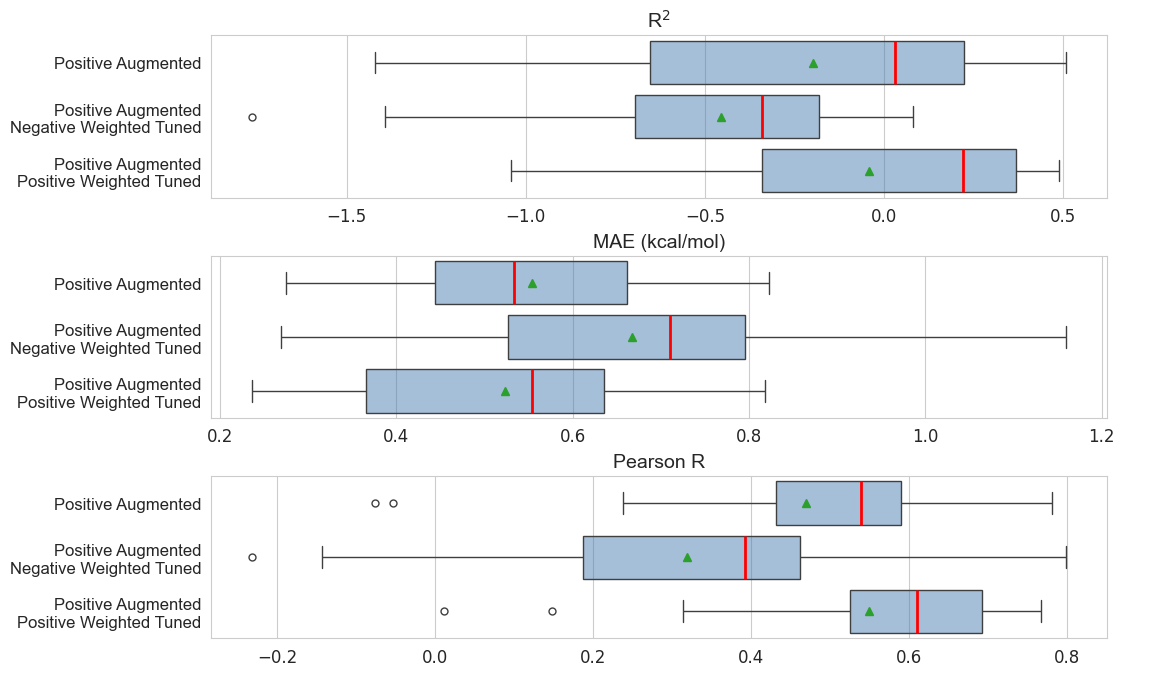

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


selected_methods = {
    "positive augmented": "Positive Augmented",
    "hybrid weighted_tuned_negative": "Positive Augmented\nNegative Weighted Tuned",
    "hybrid weighted tuned": "Positive Augmented\nPositive Weighted Tuned",
}
results = []
for df in result_dfs:
    method = df["method"].iloc[0]
    if method not in selected_methods:
        continue
    for label, subdf in df.groupby("idx"):
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "method": method,
                "metrics": "R$^2$",
                "value": r2_score(subdf["y_true"], subdf["y_pred"]),
            }
        )
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "method": method,
                "metrics": "MAE",
                "value": mean_absolute_error(subdf["y_true"], subdf["y_pred"]),
            }
        )
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "method": method,
                "metrics": "Pearson R",
                "value": pearsonr(subdf["y_true"], subdf["y_pred"])[0],
            }
        )
with sns.axes_style("whitegrid"):
    g = sns.catplot(
        pd.DataFrame(results),
        y="method",
        x="value",
        row="metrics",
        kind="box",
        sharex=False,
        boxprops={"facecolor": (0.3, 0.5, 0.7, 0.5)},
        medianprops={"color": "r", "linewidth": 2},
        facet_kws=dict(despine=False),
        showmeans=True,
    )
    g.figure.set_size_inches(12, 7)
    g.tight_layout()
    g.set_xlabels("")
    g.set_ylabels("")
    g.set_yticklabels(selected_methods.values(), fontfamily="Arial", fontsize=12)
    for idx, ((i, j, k), data_ijk) in enumerate(g.facet_data()):
        ax = g.facet_axis(i, j, k)
        if idx == 0:
            ax.set_title("R$^2$", fontsize=14, fontfamily="Arial")
        if idx == 1:
            ax.set_title("MAE (kcal/mol)", fontsize=14, fontfamily="Arial")
        if idx == 2:
            ax.set_title("Pearson R", fontsize=14, fontfamily="Arial")
    for idx, ((i, j, k), data_ijk) in enumerate(g.facet_data()):
        ax = g.facet_axis(i, j, k)
        for i, label in enumerate(ax.get_xticklabels()):
            label.set_fontsize(12)

## Total results

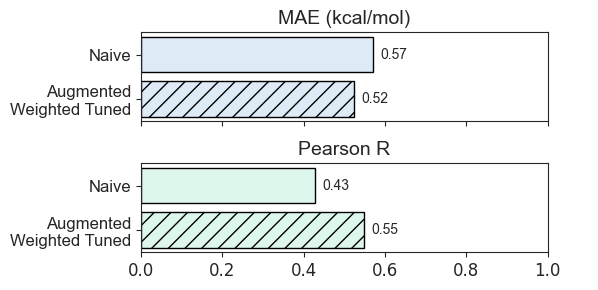

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


selected_methods = {
    "naive": "Naive",
    "hybrid weighted tuned": "Augmented\nWeighted Tuned",
}
results = []
for df in result_dfs:
    method = df["method"].iloc[0]
    if method not in selected_methods:
        continue
    for label, subdf in df.groupby("idx"):
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "method": method,
                "metrics": "MAE",
                "value": mean_absolute_error(subdf["y_true"], subdf["y_pred"]),
            }
        )
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "method": method,
                "metrics": "Pearson R",
                "value": pearsonr(subdf["y_true"], subdf["y_pred"])[0],
            }
        )
with sns.axes_style("ticks"):
    g = sns.catplot(
        pd.DataFrame(results),
        y="method",
        x="value",
        row="metrics",
        kind="bar",
        sharex=True,
        errorbar=None,
        facet_kws=dict(despine=False, xlim=(0, 1)),
    )
    g.set_xlabels("")
    g.set_ylabels("")
    g.set_yticklabels(selected_methods.values(), fontfamily="Arial", fontsize=12)
    g.figure.set_size_inches(6, 3)
    for idx, ((i, j, k), data_ijk) in enumerate(g.facet_data()):
        ax = g.facet_axis(i, j, k)
        if idx == 0:
            for bar in ax.containers[0]:
                bar.set_edgecolor("black")
                bar.set_facecolor(color="#DEEBF7")
            else:
                bar.set_hatch("//")
            ax.set_title("MAE (kcal/mol)", fontsize=14, fontfamily="Arial")
        if idx == 1:
            for bar in ax.containers[0]:
                bar.set_edgecolor("black")
                bar.set_facecolor(color="#DEF7EC")
            else:
                bar.set_hatch("//")
            ax.set_title("Pearson R", fontsize=14, fontfamily="Arial")
    for idx, ((i, j, k), data_ijk) in enumerate(g.facet_data()):
        ax = g.facet_axis(i, j, k)
        for i, label in enumerate(ax.get_xticklabels()):
            label.set_fontsize(12)
        ax.bar_label(
            container=ax.containers[0],
            fmt="%.2f",
            padding=5,
            fontfamily="Arial",
            fontsize=10,
        )
g.tight_layout()
g.figure.savefig("img/Training_Strategies_Comparison.png", dpi=300)

### Case example

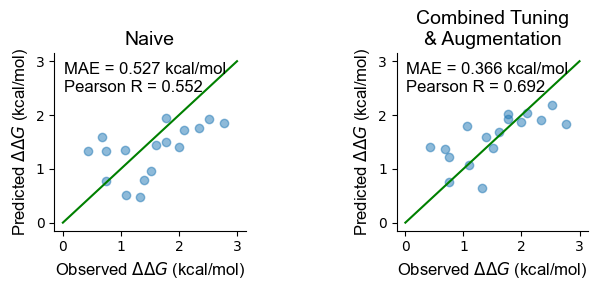

In [10]:
selected_methods = {
    "naive": "Naive",
    "hybrid weighted tuned": "Combined Tuning\n& Augmentation",
}
idx = 0
g = sns.FacetGrid(
    pd.concat(
        [
            df
            for df in result_dfs
            if (df["idx"].iloc[0] == idx) and (df["method"].iloc[0] in selected_methods)
        ]
    ),
    col="method",
    sharey=False,
)
for (i, j, k), data_ijk in g.facet_data():
    ax = g.facet_axis(i, j, k)
    ax.plot([0, 3], [0, 3], color="green", linestyle="-")
    ax.scatter(
        x=data_ijk["y_true"],
        y=data_ijk["y_pred"],
        alpha=0.5,
    )
    ax.text(
        0.05,
        0.95,
        f"MAE = {mean_absolute_error(data_ijk['y_true'], data_ijk['y_pred']):5.3f} kcal/mol",
        transform=ax.transAxes,
        fontsize=12,
        fontfamily="Arial",
        verticalalignment="top",
    )
    ax.text(
        0.05,
        0.85,
        f"Pearson R = {pearsonr(data_ijk['y_true'], data_ijk['y_pred'])[0]:5.3f}",
        transform=ax.transAxes,
        fontsize=12,
        fontfamily="Arial",
        verticalalignment="top",
    )
    ax.set_title(
        selected_methods[data_ijk["method"].iloc[0]], fontfamily="Arial", fontsize=14
    )
    ax.set_xlabel(
        r"Observed $\Delta\Delta\it{G}$ (kcal/mol)",
        fontdict={"size": 12, "fontfamily": "Arial"},
    )
    ax.set_ylabel(
        r"Predicted $\Delta\Delta\it{G}$ (kcal/mol)",
        fontdict={"size": 12, "fontfamily": "Arial"},
    )
g.figure.subplots_adjust(wspace=5, hspace=0.02)
g.figure.set_size_inches(7, 3)
g.tight_layout()
g.figure.savefig("img/LORO_regression_plot.png", dpi=300)